<a href="https://colab.research.google.com/github/Aziz4785/ML/blob/master/waveglow_for_music.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import librosa
import numpy as np
import os
from IPython.display import Audio, display
import os
import math
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import scipy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import psutil
import os

#best loss acheive : around -2.4 15 epochs

In [2]:
# Download the fma_small.zip dataset directly
!wget https://os.unil.cloud.switch.ch/fma/fma_small.zip #it contains 8000 songs

# Unzip the file (the -q flag keeps the output quiet so it doesn't crash your browser)
!unzip -q fma_small.zip

# Remove the zip file to free up disk space
!rm fma_small.zip

--2026-04-28 14:14:24--  https://os.unil.cloud.switch.ch/fma/fma_small.zip
Resolving os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)... 86.119.28.16, 2001:620:5ca1:201::214
Connecting to os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)|86.119.28.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7679594875 (7.2G) [application/zip]
Saving to: ‘fma_small.zip’

fma_small.zip       100%[===================>]   7.15G  23.2MB/s    in 5m 26s  

2026-04-28 14:19:52 (22.5 MB/s) - ‘fma_small.zip’ saved [7679594875/7679594875]



In [3]:

SR = 16000
SEQ_LEN = 16000

AUDIO_DIR = '/content/fma_small'

np.random.seed(42)

LISTEN_INDICES = [20, 100, 250]


def play_audio(y, sr=SR, title=""):
    print(title)
    display(Audio(y, rate=sr))


def plot_waveform(signal, sr, title="Waveform"):
    signal = np.asarray(signal)
    t = np.arange(len(signal)) / sr

    # Compute stats
    sig_min = signal.min()
    sig_max = signal.max()
    sig_std = signal.std()

    # If std is invalid → do not plot
    if sig_std is None or np.isnan(sig_std):
        print("⚠️ Invalid standard deviation. Skipping plot.")
        return

    # Successive-sample measures
    if len(signal) < 2:
        lag1_corr = np.nan
        mean_abs_diff = np.nan
        closeness_score = np.nan
    else:
        if len(signal) < 3 or sig_std == 0:
            lag2_corr = np.nan
        else:
            lag2_corr = np.corrcoef(signal[:-2], signal[2:])[0, 1]
        diffs = np.abs(np.diff(signal))
        mean_abs_diff = diffs.mean()

        if sig_std == 0:
            lag1_corr = np.nan
        else:
            lag1_corr = np.corrcoef(signal[:-1], signal[1:])[0, 1]

        sig_range = sig_max - sig_min
        if sig_range == 0:
            closeness_score = 1.0
        else:
            closeness_score = 1 - (mean_abs_diff / sig_range)

    # Check audibility
    audible_note = ""
    if sig_std < 1e-3:
        audible_note = " ⚠️ (signal is not audible)"

    # Build title
    full_title = (
        f"{title}\n"
        f"lag-1 corr: {lag1_corr:.5f}, "
        f"lag-2 corr: {lag2_corr:.5f}, "
        f"mean |diff|: {mean_abs_diff:.5f}, "
        f"closeness: {closeness_score:.5f}"
        f"{audible_note}"
    )

    plt.figure(figsize=(14, 4))
    plt.plot(t, signal, linewidth=0.7)
    plt.title(full_title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_zoom(sig, sr, start_t, end_t, title="Zoomed waveform"):
    start = int(start_t * sr)
    end = int(end_t * sr)

    if len(sig) < end:
        print("Signal too short")
        return

    zoom = sig[start:end]
    t = np.linspace(start_t, end_t, len(zoom))

    plt.figure(figsize=(8,3))
    plt.plot(t, zoom)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.grid(True)
    plt.show()


# ----------------------------
# (for listening)
# ----------------------------
all_paths = []

for root, _, files in os.walk(AUDIO_DIR):
    for f in files:
        if f.endswith(".mp3"):
            all_paths.append(os.path.join(root, f))

print("Total files:", len(all_paths))

# ----------------------------
#  Listen BEFORE clipping
# ----------------------------


# for idx in LISTEN_INDICES:
#     path = all_paths[idx]
#     y, _ = librosa.load(path, sr=SR, mono=True)
#     play_audio(y, SR, f"Original audio #{idx}")
#     plot_waveform(y, SR, title=f"Waveform — Original #{idx}")

# ----------------------------
#  extract RANDOM SEGMENTS
# ----------------------------
def load_random_segments(path, n_segments=3):
    y, _ = librosa.load(path, sr=SR, mono=True)
    segments = []

    for _ in range(n_segments):
        if len(y) > SEQ_LEN:
            start = np.random.randint(0, len(y) - SEQ_LEN)
            segment = y[start:start + SEQ_LEN]
        else:
            segment = np.pad(y, (0, SEQ_LEN - len(y)))

        segments.append(segment)

    return segments


signals = []

for path in all_paths:
    try:
        segs = load_random_segments(path, n_segments=3)
        signals.extend(segs)
    except Exception as e:
        print("Skipping:", path, e)

signals = np.array(signals)

print("\nFinal shape:", signals.shape)
# shape will be (N * 3, 50000)



Total files: 8000


/tmp/ipykernel_2316/1795445062.py:124: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping: /content/fma_small/133/133297.mp3 


/tmp/ipykernel_2316/1795445062.py:124: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping: /content/fma_small/099/099134.mp3 


/tmp/ipykernel_2316/1795445062.py:124: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping: /content/fma_small/108/108925.mp3 


/tmp/ipykernel_2316/1795445062.py:124: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_2316/1795445062.py:124: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_2316/1795445062.py:124: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=SR, mono=True)
/usr/local/lib/python3.12/dist


Final shape: (23991, 16000)



--- Listening AFTER processing ---

--- Listening AFTER processing ---
Processed audio #20, segment 0


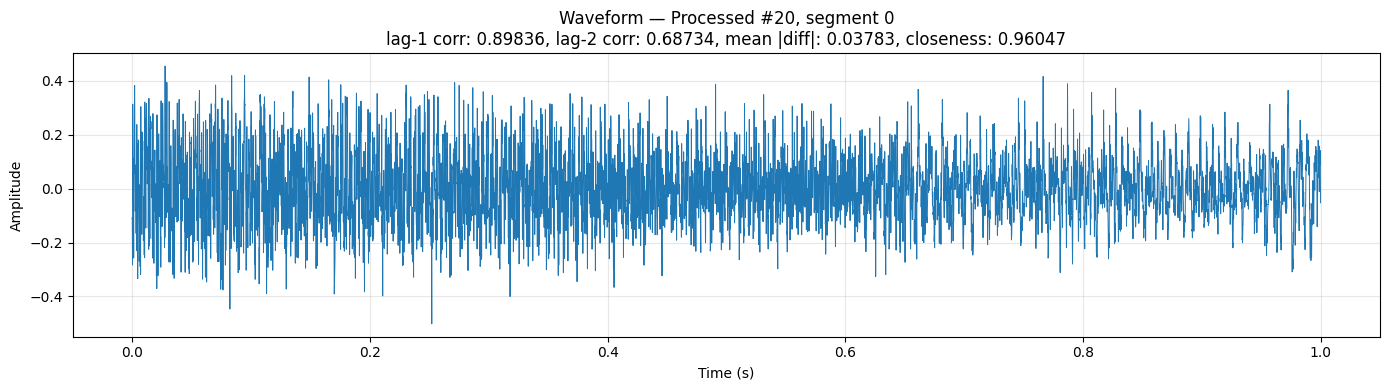

Signal too short


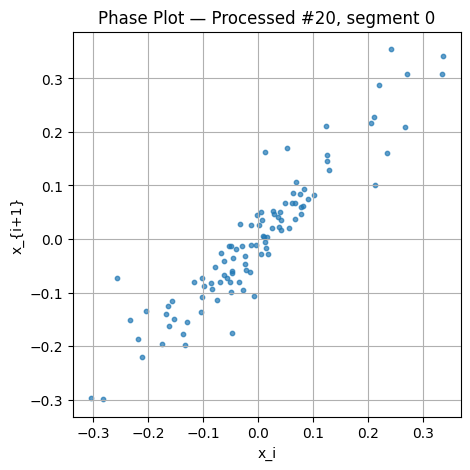

Processed audio #20, segment 1


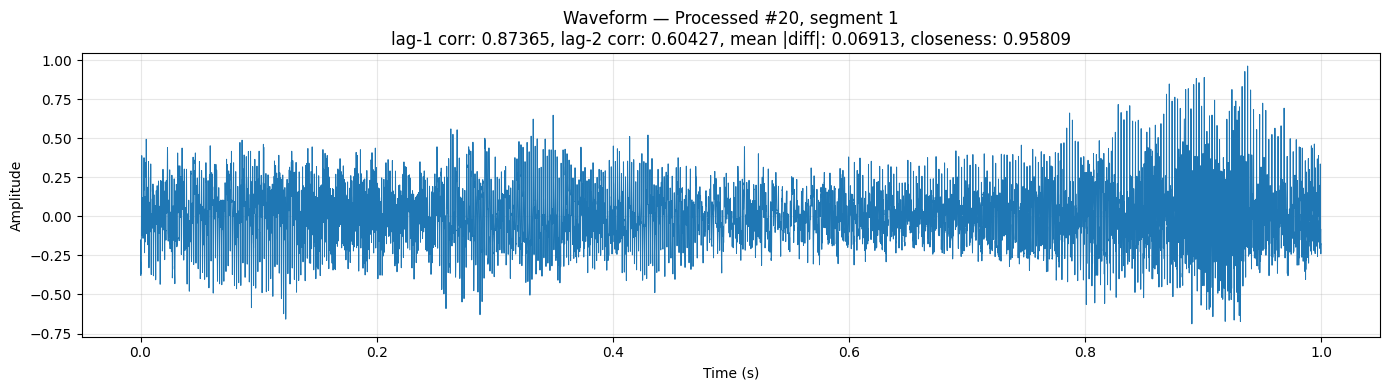

Signal too short


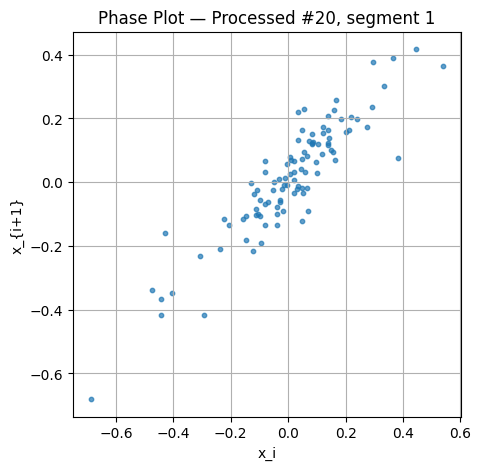

Processed audio #20, segment 2


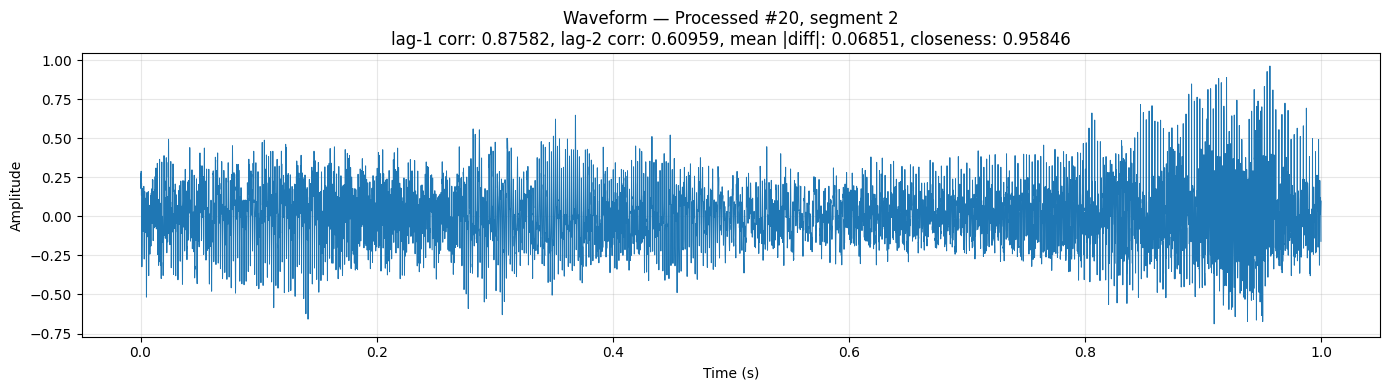

Signal too short


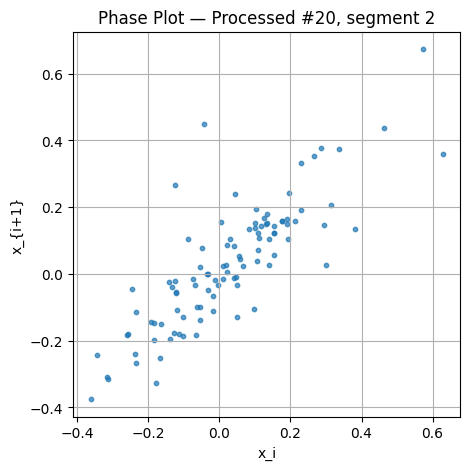

Processed audio #100, segment 0


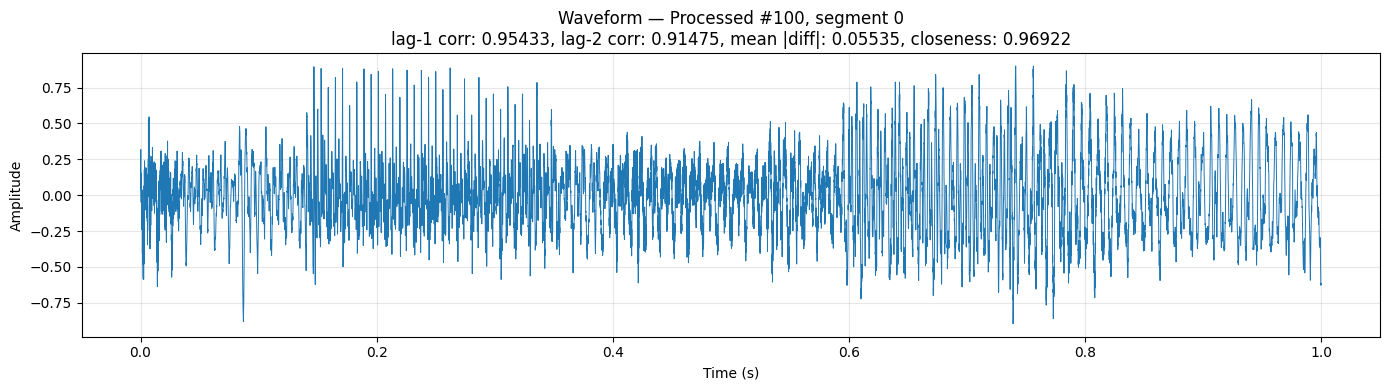

Signal too short


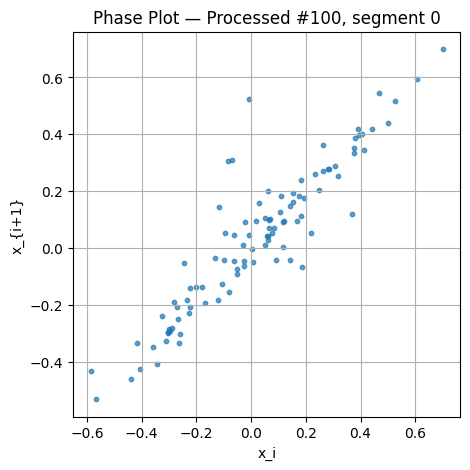

Processed audio #100, segment 1


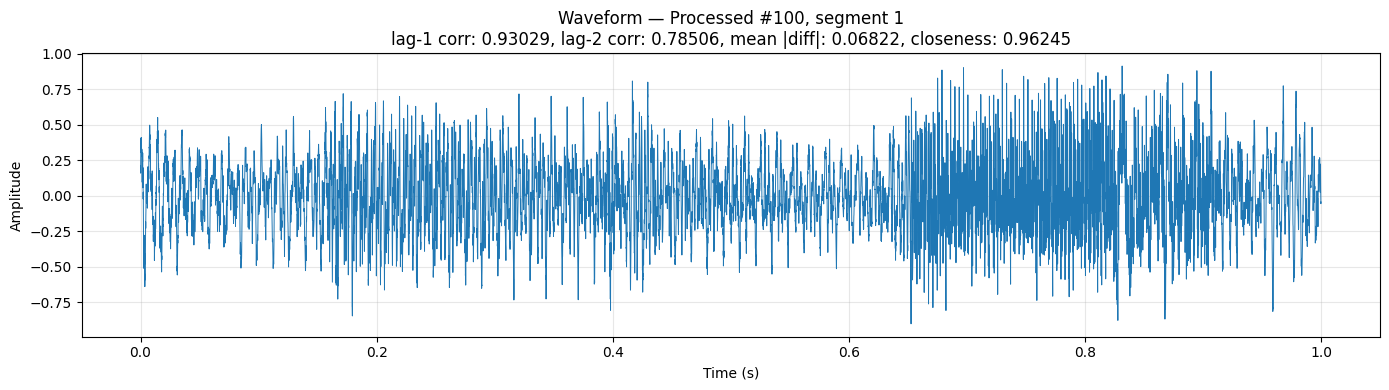

Signal too short


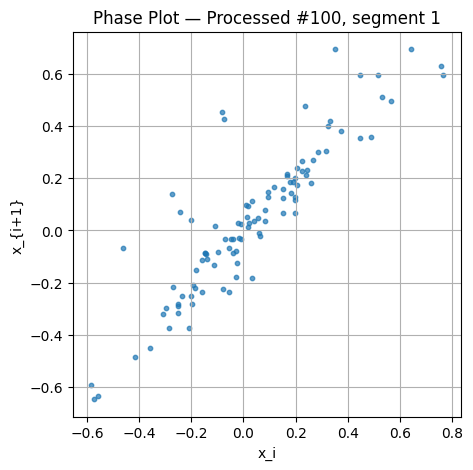

Processed audio #100, segment 2


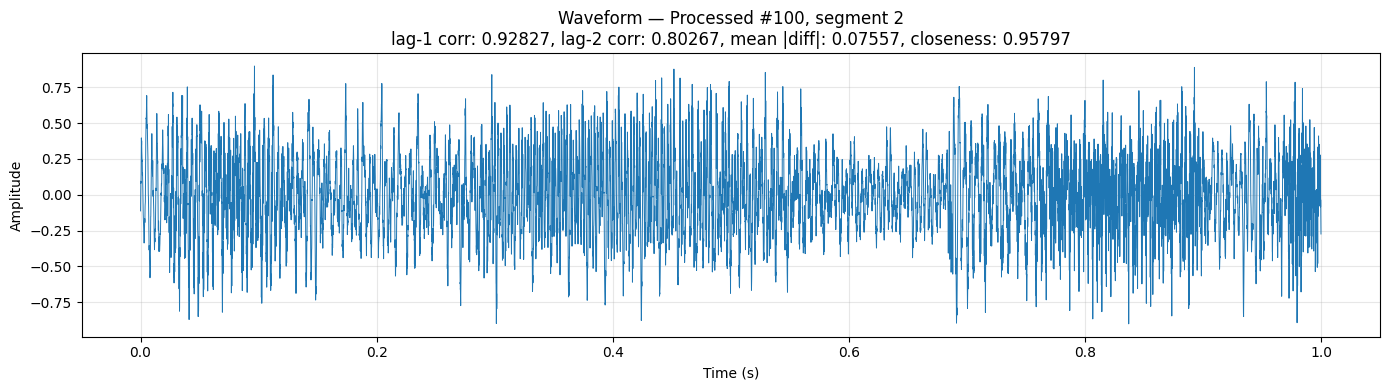

Signal too short


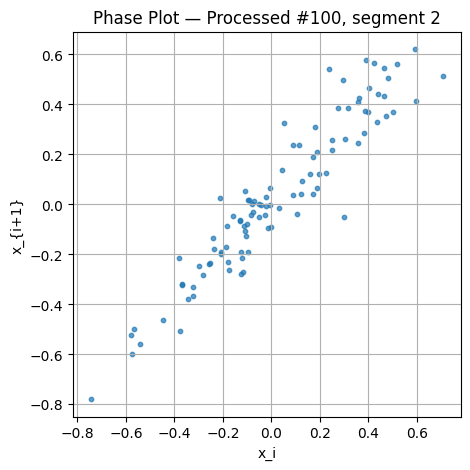

Processed audio #250, segment 0


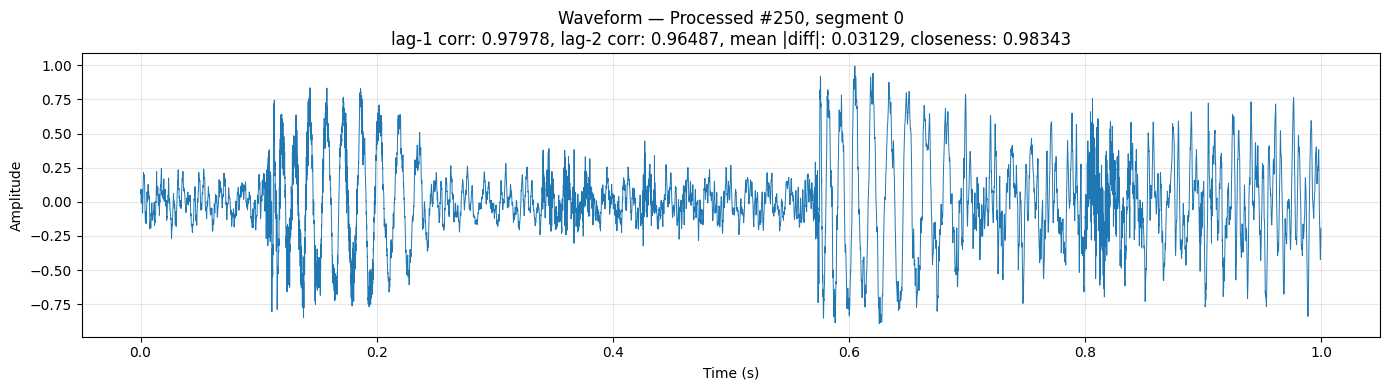

Signal too short


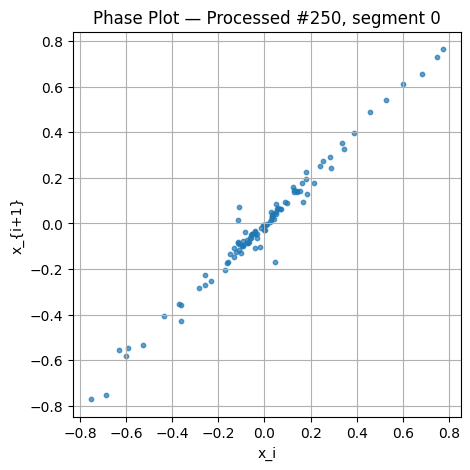

Processed audio #250, segment 1


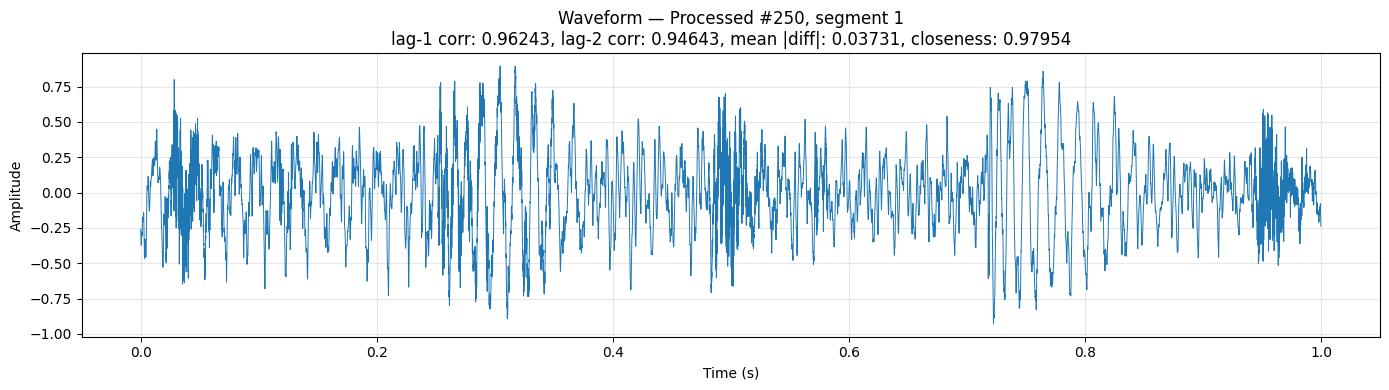

Signal too short


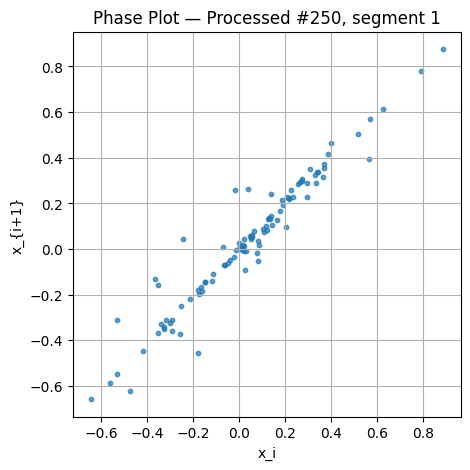

Processed audio #250, segment 2


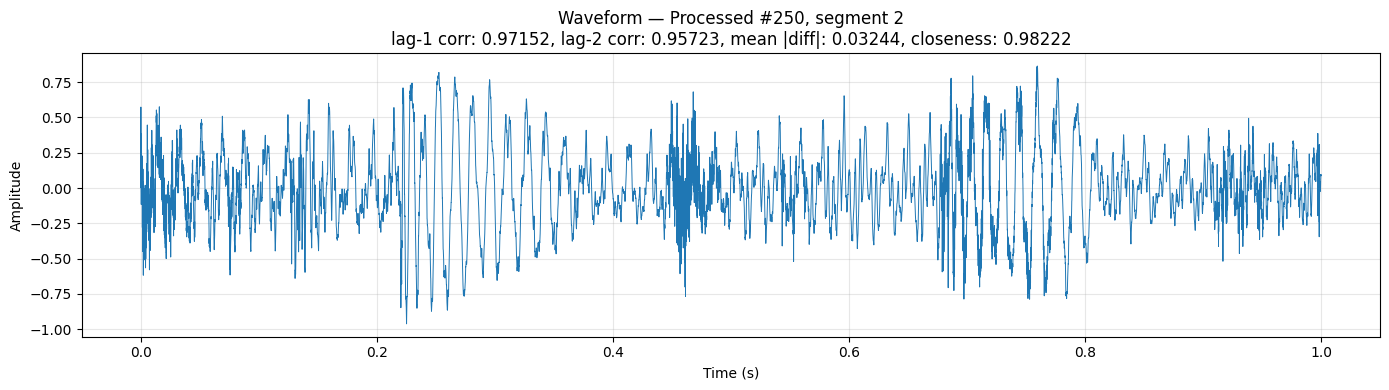

Signal too short


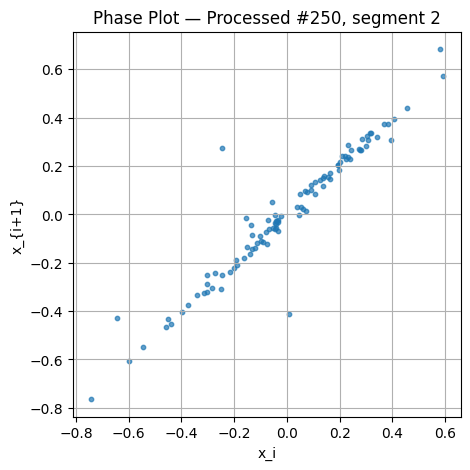

In [4]:
# ----------------------------
#  Listen AFTER processing
# ----------------------------
print("\n--- Listening AFTER processing ---")
import numpy as np
import matplotlib.pyplot as plt

print("\n--- Listening AFTER processing ---")

for idx in LISTEN_INDICES:
    base = idx * 3

    for s in range(3):
        sig = signals[base + s]

        # --- Play + waveform ---
        play_audio(sig, SR, f"Processed audio #{idx}, segment {s}")
        plot_waveform(sig, SR, title=f"Waveform — Processed #{idx}, segment {s}")
        plot_zoom(sig,SR,1.0,1.02,title=f"Zoomed Waveform (1.0–1.02s) — #{idx}, segment {s}")
        # -----------------------------
        # Phase plot (100 random points)
        # -----------------------------
        N = 100

        # Avoid last index because of i+1
        if len(sig) < 2:
            continue  # skip if too short

        indices = np.random.randint(0, len(sig) - 1, size=N)

        xi = sig[indices]
        xi_plus_1 = sig[indices + 1]

        # Plot phase space
        plt.figure(figsize=(5, 5))
        plt.scatter(xi, xi_plus_1, s=10, alpha=0.7)

        plt.xlabel("x_i")
        plt.ylabel("x_{i+1}")
        plt.title(f"Phase Plot — Processed #{idx}, segment {s}")
        plt.grid(True)

        plt.show()

In [5]:
np.save("/content/signals.npy", signals)

In [23]:
import time

class Config:
    DATA_PATH = "/content/signals.npy"

    SEQ_LEN = 16000 #power of 2
    IN_CHANNELS = 1

    BATCH_SIZE = 24
    NUM_WORKERS = 2

    # Glow hyperparameters for 1D data
    ZI_SIZE = 2 #n_early_size in the offical code
    N_GROUPS = 8 #8
    N_FLOWS = 12 #12
    SPLIT_EVERY= 4
    HIDDEN_CHANNELS = 256

    #wn parameters :
    WN_LAYERS = 8 #put 8
    WN_HIDDEN_CHANNELS = 256 # 256

    BASE_LR = 1e-4
    EPOCHS = 200

    # For numerical stability on long sequences
    GRAD_CLIP = 5.0
    PLOT_EVERY = 5

    DEBUG = False

config = Config()


In [24]:
class SignalDataset(Dataset):
    def __init__(self, data_path, seq_len, normalize=True):
        self.data_path = data_path
        self.seq_len = seq_len
        self.normalize = normalize

        if data_path.endswith('.npy'):
            data = np.load(data_path)
            data = torch.from_numpy(data).float()
        elif data_path.endswith(('.pt', '.pth')):
            data = torch.load(data_path)
            if isinstance(data, np.ndarray):
                data = torch.from_numpy(data).float()
            elif not torch.is_tensor(data):
                data = torch.tensor(data, dtype=torch.float32)
            else:
                data = data.float()
        else:
            raise ValueError("Unsupported file format. Use .npy, .pt, or .pth")

        if data.ndim == 3:
            # (N, 1, T) -> (N, T)
            if data.shape[1] == 1:
                data = data.squeeze(1)
            else:
                raise ValueError(f"Expected channel dimension = 1, got {tuple(data.shape)}")
        elif data.ndim != 2:
            raise ValueError(f"Expected data with 2 or 3 dims, got shape {tuple(data.shape)}")

        if data.shape[-1] != seq_len:
            raise ValueError(
                f"Expected sequence length {seq_len}, got {data.shape[-1]}. "
                "Either change Config.SEQ_LEN or reshape your dataset first."
            )

        self.data = data.contiguous()

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]


dataset = SignalDataset(
    data_path=config.DATA_PATH,
    seq_len=config.SEQ_LEN,
    normalize=True,
)

if config.DEBUG:
    dataset.data = dataset.data[:5]

train_loader = DataLoader(
    dataset,
    batch_size=1 if config.DEBUG else config.BATCH_SIZE,
    shuffle=not config.DEBUG,          # deterministic in debug
    num_workers=0 if config.DEBUG else config.NUM_WORKERS,
    drop_last=True,
    pin_memory=not config.DEBUG,
)

print("Loaded dataset:", dataset.data.shape)


Loaded dataset: torch.Size([23991, 16000])


torch.Size([16000])
torch.Size([16000])


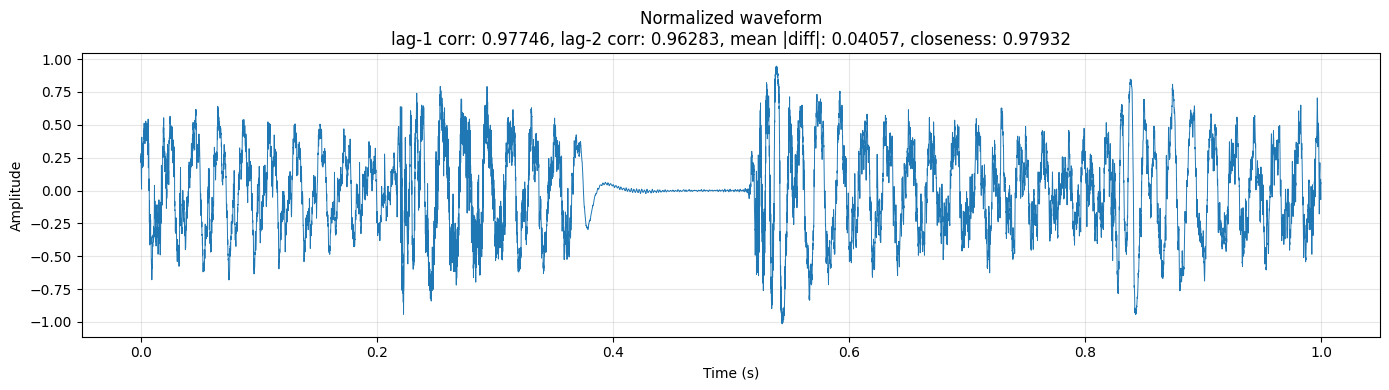

In [25]:


sample1 = dataset[1]          # shape: (T)
print(sample1.shape)
signal1 = sample1.squeeze(0)   # shape: (T,)
print(signal1.shape)
plot_waveform(signal1.numpy(), sr=16000, title="Normalized waveform")

In [26]:
def generate_and_show_signals(model, epoch, num_samples=4,  remove_outliers = True, device='cuda'):
    model.eval()

    with torch.no_grad():
        print("generating sample ...")
        generated = model.sample(
            num_samples=num_samples,
            device=device,
        ).cpu()
        print("sample generated ! ")
    for i in range(num_samples):
        signal = generated[i, 0].numpy()
        print("signal shape : ",signal.shape)

        #audio = signal / (np.max(np.abs(signal)) + 1e-8)

        if remove_outliers:
          signal = np.clip(signal, -20, 20)

        audio = signal
        plot_waveform(
            signal=audio,
            sr=SR,
            title=f"Generated sample {i+1} at epoch {epoch}"
        )

        play_audio(
            audio,
            sr=SR,
            title=f"Sample {i+1}"
        )

    model.train()


In [27]:
@torch.jit.script
def gated_tanh_nonlinearity(input_a, n_channels):
    n_channels_int = n_channels[0]
    t_act = torch.tanh(input_a[:, :n_channels_int, :])
    s_act = torch.sigmoid(input_a[:, n_channels_int:, :])
    acts = t_act * s_act
    return acts

In [28]:
from torch.nn.utils.parametrizations import weight_norm

@torch.jit.script
def fused_gated_tanh_nonlinearity(in_acts, n_channels: int):
    t_act = torch.tanh(in_acts[:, :n_channels, :])
    s_act = torch.sigmoid(in_acts[:, n_channels:, :])
    return t_act * s_act

class WN(torch.nn.Module):
    """
    This is the WaveNet like layer for the affine coupling. The primary difference
    from WaveNet is the convolutions need not be causal. There is also no dilation
    size reset. The dilation only doubles on each layer.

    """
    def __init__(self, n_in_channels, kernel_size):
        print(f"   WN initiliazed with n_in_channels = {n_in_channels} , kernel_size = {kernel_size} , n_layers = {config.WN_LAYERS}")
        super(WN, self).__init__()

        self.n_layers = config.WN_LAYERS
        self.n_channels = config.WN_HIDDEN_CHANNELS
        assert(kernel_size % 2 == 1)
        assert(self.n_channels % 2 == 0)

        self.in_layers = torch.nn.ModuleList()
        self.res_skip_layers = torch.nn.ModuleList()

        start = torch.nn.Conv1d(n_in_channels, self.n_channels, 1)

        start = weight_norm(start, name='weight')
        self.start = start

        end = torch.nn.Conv1d(self.n_channels, 2 * n_in_channels, 1)
        end.weight.data.zero_()
        end.bias.data.zero_()
        self.end = end

        for i in range(self.n_layers):
            dilation = 2 ** i
            padding = int((kernel_size * dilation - dilation) / 2)
            in_layer = torch.nn.Conv1d(self.n_channels, 2 * self.n_channels, kernel_size,
                                       dilation=dilation, padding=padding)
            in_layer = weight_norm(in_layer, name='weight')
            self.in_layers.append(in_layer)

            # last one is not necessary
            if i < self.n_layers - 1:
                res_skip_channels = 2 * self.n_channels
            else:
                res_skip_channels = self.n_channels
            res_skip_layer = torch.nn.Conv1d(self.n_channels, res_skip_channels, 1)
            res_skip_layer = torch.nn.utils.weight_norm(res_skip_layer, name='weight')
            self.res_skip_layers.append(res_skip_layer)

    def forward(self, forward_input):

        audio = self.start(forward_input)
        output = torch.zeros_like(audio)

        for i in range(self.n_layers):
            in_acts = self.in_layers[i](audio)
            # # Split into two halves for the gated activation, commented for speed and replaced by fused activation
            # t_act = torch.tanh(in_acts[:, :self.n_channels, :])
            # s_act = torch.sigmoid(in_acts[:, self.n_channels:, :])
            # acts = t_act * s_act
            acts = fused_gated_tanh_nonlinearity(in_acts, self.n_channels)

            res_skip_acts = self.res_skip_layers[i](acts)
            if i < self.n_layers - 1:
                audio = audio + res_skip_acts[:, :self.n_channels, :]
                output = output + res_skip_acts[:, self.n_channels:, :]
            else:
                output = output + res_skip_acts

        return self.end(output)

In [29]:


class Invertible1x1Conv1D(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        W = np.linalg.qr(np.random.randn(num_channels, num_channels))[0].astype(np.float32)

        # LU decomposition
        P, L, U = scipy.linalg.lu(W)

        self.register_buffer('P', torch.from_numpy(P))  # fixed, not trained
        self.L = nn.Parameter(torch.from_numpy(L))
        self.U = nn.Parameter(torch.from_numpy(U))

        # Store log-diagonal of U separately for numerical stability
        s = np.diag(U)
        self.register_buffer('sign_s', torch.from_numpy(np.sign(s)))
        self.log_s = nn.Parameter(torch.from_numpy(np.log(np.abs(s))))

    def _assemble_weight(self):
        n = self.L.shape[0]
        L = torch.tril(self.L, diagonal=-1) + torch.eye(n, device=self.L.device)
        U = torch.triu(self.U, diagonal=1) + torch.diag(self.sign_s * torch.exp(self.log_s))
        return self.P @ L @ U

    def _logdet(self, t):
        # log|det W| = sum of log_s, guaranteed finite
        return self.log_s.sum() * t

    def forward(self, x, logdet=None, reverse=False,debug_sampling=False):
        B, C, T = x.shape

        weight = self._assemble_weight()
        dlogdet = self._logdet(T)

        if not reverse:
            z = F.conv1d(x, weight.view(C, C, 1))
            if logdet is not None:
                logdet = logdet + dlogdet
        else:

            weight_inv = torch.inverse(weight.double()).float()
            z = F.conv1d(x, weight_inv.view(C, C, 1))
            if logdet is not None:
                logdet = logdet - dlogdet

        return (z, logdet) if logdet is not None else z


class Invertible1x1Conv1D_notLU(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        w_init = np.linalg.qr(np.random.randn(num_channels, num_channels))[0].astype(np.float32)
        w_init = torch.from_numpy(w_init)
        self.weight = nn.Parameter(w_init)

    def _assemble_weight(self):
        return self.weight

    def _logdet(self, t):
        sign, logabsdet = torch.linalg.slogdet(self.weight.double())
        if sign == 0:
            raise RuntimeError("determinant is null, cannot invert the weight matrix")
        return logabsdet.float() * t

    def forward(self, x, logdet=None, reverse=False,debug_sampling=False):
        B, C, T = x.shape

        weight = self._assemble_weight()
        dlogdet = self._logdet(T)

        if not reverse:
            z = F.conv1d(x, weight.view(C, C, 1))
            if logdet is not None:
                logdet = logdet + dlogdet
        else:

            weight_inv = torch.inverse(weight.double()).float()

            z = F.conv1d(x, weight_inv.view(C, C, 1))
            if logdet is not None:
                logdet = logdet - dlogdet

        return (z, logdet) if logdet is not None else z


class AffineCoupling1D(nn.Module):
    def __init__(self, num_channels, hidden_channels):
        super().__init__()
        self.num_channels = num_channels
        self.in_channels = num_channels // 2
        # WN takes in_channels and outputs 2*in_channels (for log_s and b)
        self.f = WN(self.in_channels, kernel_size=3)

    def forward(self, x, logdet=None, step_in_epoch=0, reverse=False, debug_sampling=False):
        t0 = time.perf_counter()
        n_half = int(x.size(1) / 2)
        x_0 = x[:, :n_half, :]
        x_1 = x[:, n_half:, :]

        output = self.f(x_0)
        log_s = output[:, n_half:, :]
        b = output[:, :n_half, :]

        if not reverse:
            scale = torch.exp(log_s)
            x_1 = scale * x_1 + b
            if logdet is not None:
                logdet = logdet + torch.sum(log_s, dim=(1, 2))

        else:
            x_1 = (x_1 - b) * torch.exp(-log_s)
            if logdet is not None:
                logdet = logdet - torch.sum(log_s, dim=(1, 2))

        x = torch.cat([x_0, x_1], 1)

        return (x, logdet) if logdet is not None else x

In [30]:
class StepOfFlow1D(nn.Module):
    def __init__(self, num_channels, hidden_channels):
        super().__init__()
        self.invconv = Invertible1x1Conv1D(num_channels)
        self.coupling = AffineCoupling1D(num_channels, hidden_channels)

    def forward(self, x, logdet=None, reverse=False,step_in_epoch = 0, debug_sampling=False):
      if not reverse:
          prev_logdet = logdet.clone()
          x, logdet = self.invconv(x, logdet, reverse=False)
          prev_logdet = logdet.clone()
          x, logdet = self.coupling(x, logdet, step_in_epoch=step_in_epoch, reverse=False)

      else:
          x, logdet = self.coupling(x, logdet, reverse=True,debug_sampling=debug_sampling)
          x, logdet = self.invconv(x, logdet, reverse=True,debug_sampling= debug_sampling)

      return (x, logdet) if logdet is not None else x


In [31]:
def preprocess_signal(x):
    return x.float()


def postprocess_signal(x):
    return x





def split_reverse_1d(zkeep, zi, sigma=1.0):
    """
    - concatenate early latent back
    """
    return torch.cat((sigma * zi, zkeep), dim=1)


def split_forward_1d(x, n_early_size):
    """
    WaveGlow-style split:
    - remove first channels (early output)
    - keep remaining for next flows
    """
    z = x[:, :n_early_size, :]
    x = x[:, n_early_size:, :]
    return x, z

class Glow1D(nn.Module):
    def __init__(self, in_channels, seq_len,hidden_channels):
        super().__init__()

        self.in_channels = in_channels
        self.seq_len = seq_len
        self.N_FLOWS = config.N_FLOWS
        self.SPLIT_EVERY = config.SPLIT_EVERY
        self.N_GROUPS = config.N_GROUPS
        self.ZI_SIZE = config.ZI_SIZE

        # number of splits = number of times we reduce channels
        self.num_splits = config.N_FLOWS // config.SPLIT_EVERY

        self.channel_schedule = [
            self.N_GROUPS - i * self.ZI_SIZE
            for i in range(self.num_splits)
        ]

        print(self.channel_schedule)
        self.flows = nn.ModuleList()

        for i in range(self.N_FLOWS):
          group_idx = i // self.SPLIT_EVERY
          current_channels = self.channel_schedule[group_idx]

          self.flows.append(
              StepOfFlow1D(current_channels, hidden_channels)
          )
          print(f"append : flow({current_channels})")
          if (i + 1) % self.SPLIT_EVERY == 0 and (i + 1) != self.N_FLOWS:
              next_channels = self.channel_schedule[group_idx + 1]

    def forward(self, x, step_in_epoch):
        timings = {}
        x = preprocess_signal(x)
        x = x.unfold(1, config.N_GROUPS, config.N_GROUPS).permute(0, 2, 1)

        B, C, T = x.shape
        num_dims = C * T

        objective = torch.zeros(B, device=x.device)
        latents = []
        logdet = torch.zeros(B, device=x.device)

        for i, flow in enumerate(self.flows):
            x, logdet = flow(x, logdet=logdet, reverse=False, step_in_epoch=step_in_epoch)

            if (i + 1) % self.SPLIT_EVERY == 0 and (i + 1) != self.N_FLOWS:
                x, zi = split_forward_1d(x, self.ZI_SIZE)

                # add prior log-prob for this split latent
                logp_zi = -0.5 * (math.log(2 * math.pi) + zi ** 2)
                logp_zi = torch.sum(logp_zi, dim=(1, 2))
                objective = objective + logp_zi

                latents.append(zi)

        # final latent
        logp = -0.5 * (math.log(2 * math.pi) + x ** 2)
        logp = torch.sum(logp, dim=(1, 2))

        objective = objective + logdet
        objective = objective + logp
        latents.append(x)

        nll = -objective.mean()
        nll_per_dim = nll / num_dims

        return nll_per_dim, latents


    @torch.no_grad()
    def sample(self, num_samples, debug_sampling=False, device=None, sigma=1.0):
        if config.DEBUG or debug_sampling:
            print("sampling ..")
        self.eval()

        # 1. Calculate the squeezed time dimension (T // 8)
        T_squeezed = config.SEQ_LEN // config.N_GROUPS

        # 2. Compute exact latent shapes based on forward pass
        shapes = []
        for i in range(self.N_FLOWS):
            if (i + 1) % self.SPLIT_EVERY == 0 and (i + 1) != self.N_FLOWS:
                shapes.append((config.ZI_SIZE, T_squeezed))

        # Final latent takes the last remaining channels
        final_channels = self.channel_schedule[-1]
        shapes.append((final_channels, T_squeezed))

        if debug_sampling:
            print("shapes : ", shapes)

        split_idx = len(shapes) - 1

        # 3. Sample the final latent z
        z = sigma * torch.randn(num_samples, *shapes[split_idx], device=device)
        if debug_sampling:
            print("final latent shape :", z.shape)

        # 4. Reverse flows
        for i in reversed(range(self.N_FLOWS)):
            if debug_sampling:
                print("processing flow ", i)

            # REVERSE SPLIT: If forward split happened AFTER flow i,
            # we must reverse the split BEFORE reversing flow i.
            if (i + 1) % self.SPLIT_EVERY == 0 and (i + 1) != self.N_FLOWS:
                split_idx -= 1
                if debug_sampling:
                    print("concatenating with an external z")
                eps = torch.randn(num_samples, *shapes[split_idx], device=device)
                z = split_reverse_1d(zkeep=z, zi=eps, sigma=sigma)
                if debug_sampling:
                    print("after concatenation, z shape is ", z.shape)

            # APPLY REVERSE FLOW
            z, _ = self.flows[i](
                z,
                logdet=torch.zeros(num_samples, device=device),
                reverse=True
            )
            if debug_sampling:
                print("after that flow, z shape is ", z.shape)

        # 5. UNSQUEEZE (Reverse the unfold + permute from the forward pass)
        # Current z shape: (Batch, N_GROUPS, T_squeezed)
        B, C_squeezed, T_sq = z.shape
        # Revert to (Batch, 1, Seq_Len)
        z = z.permute(0, 2, 1).contiguous().view(B, 1, -1)

        if debug_sampling:
            print("After unsqueeze, final z shape:", z.shape)

        z = postprocess_signal(z)

        return z



In [32]:
def get_lr(step, warmup_steps, base_lr):
    return base_lr * min(1., step / warmup_steps)

In [33]:
import gc
gc.collect()
torch.cuda.empty_cache()

del model
del optimizer

NameError: name 'model' is not defined

In [34]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(device)

True
NVIDIA L4
cuda


creating model ...
[10, 8, 6, 4]
   WN initiliazed with n_in_channels = 5 , kernel_size = 3 , n_layers = 8
append : flow(10)
   WN initiliazed with n_in_channels = 5 , kernel_size = 3 , n_layers = 8
append : flow(10)
   WN initiliazed with n_in_channels = 5 , kernel_size = 3 , n_layers = 8
append : flow(10)
   WN initiliazed with n_in_channels = 5 , kernel_size = 3 , n_layers = 8
append : flow(10)
   WN initiliazed with n_in_channels = 4 , kernel_size = 3 , n_layers = 8
append : flow(8)
   WN initiliazed with n_in_channels = 4 , kernel_size = 3 , n_layers = 8
append : flow(8)
   WN initiliazed with n_in_channels = 4 , kernel_size = 3 , n_layers = 8
append : flow(8)
   WN initiliazed with n_in_channels = 4 , kernel_size = 3 , n_layers = 8
append : flow(8)
   WN initiliazed with n_in_channels = 3 , kernel_size = 3 , n_layers = 8
append : flow(6)
   WN initiliazed with n_in_channels = 3 , kernel_size = 3 , n_layers = 8
append : flow(6)
   WN initiliazed with n_in_channels = 3 , kernel_siz

Epoch 1/200: 100%|██████████| 999/999 [39:56<00:00,  2.40s/it, loss=-1.518007, lr=1.00e-04]


Epoch 1: average_loss = -1.451125
generating sample ...
sample generated ! 
signal shape :  (16000,)


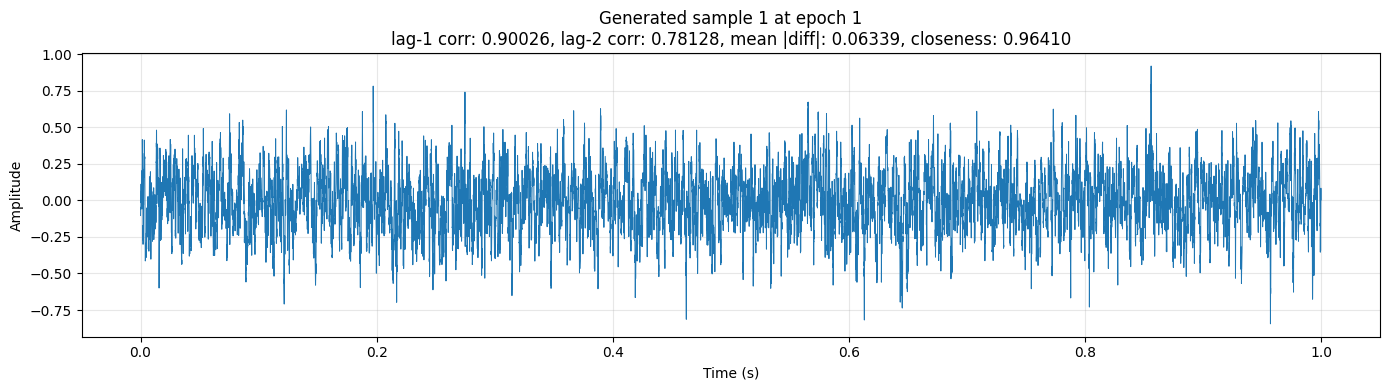

Sample 1


signal shape :  (16000,)


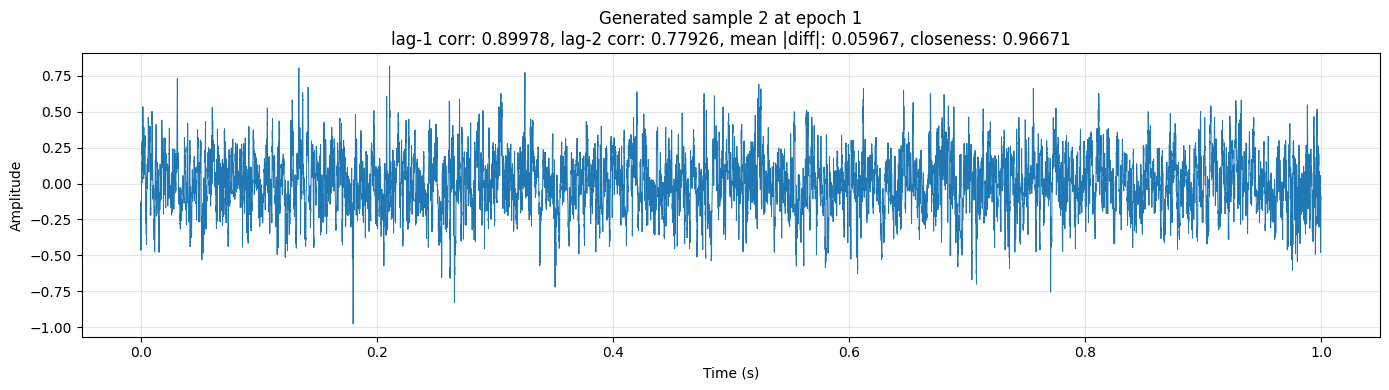

Sample 2


signal shape :  (16000,)


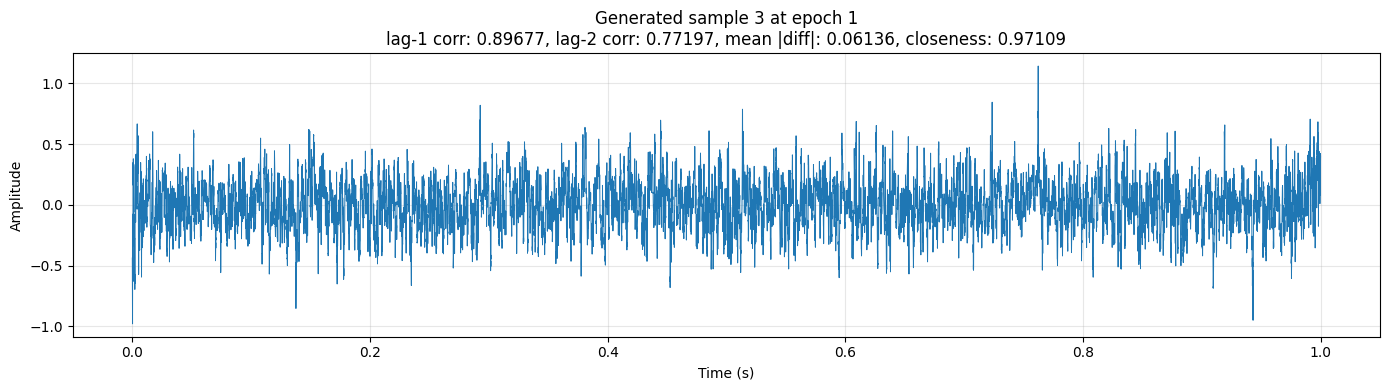

Sample 3


signal shape :  (16000,)


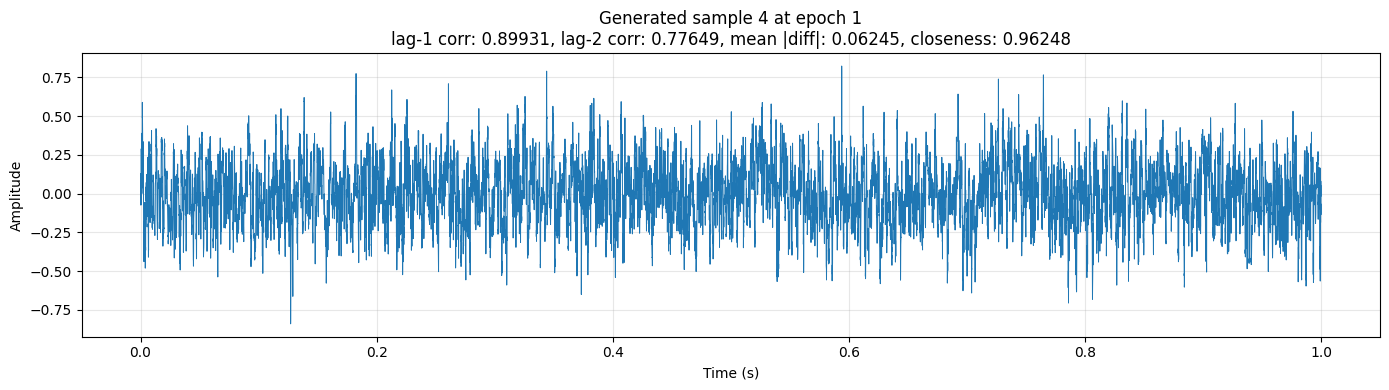

Sample 4


signal shape :  (16000,)


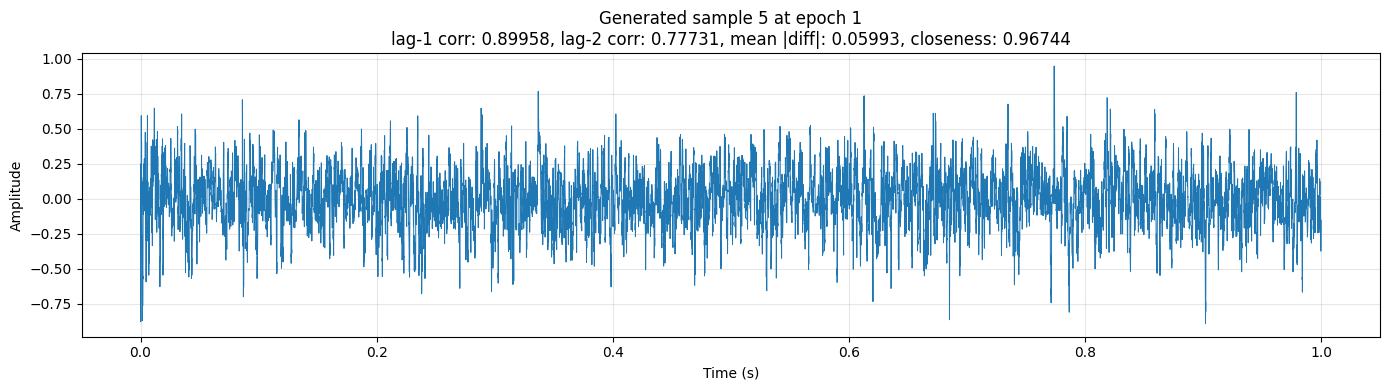

Sample 5


signal shape :  (16000,)


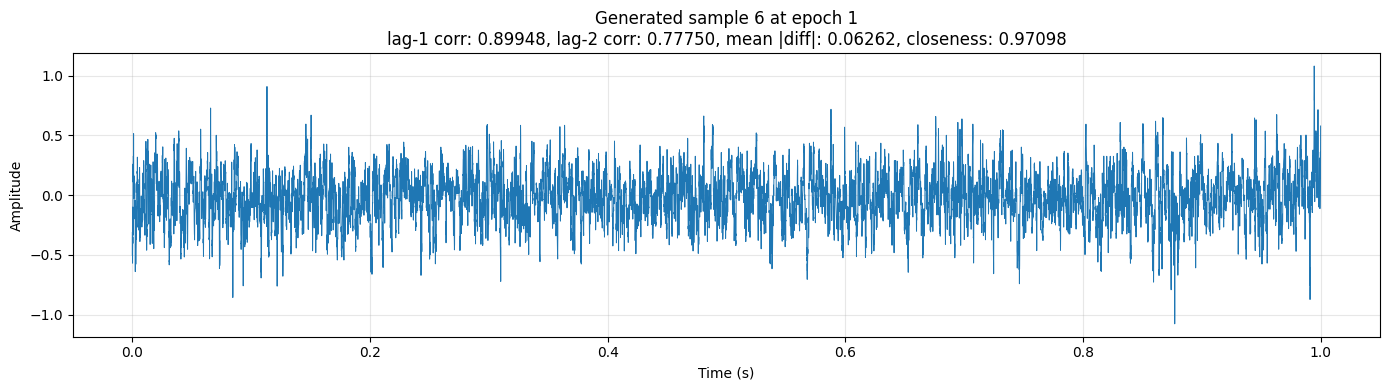

Sample 6


signal shape :  (16000,)


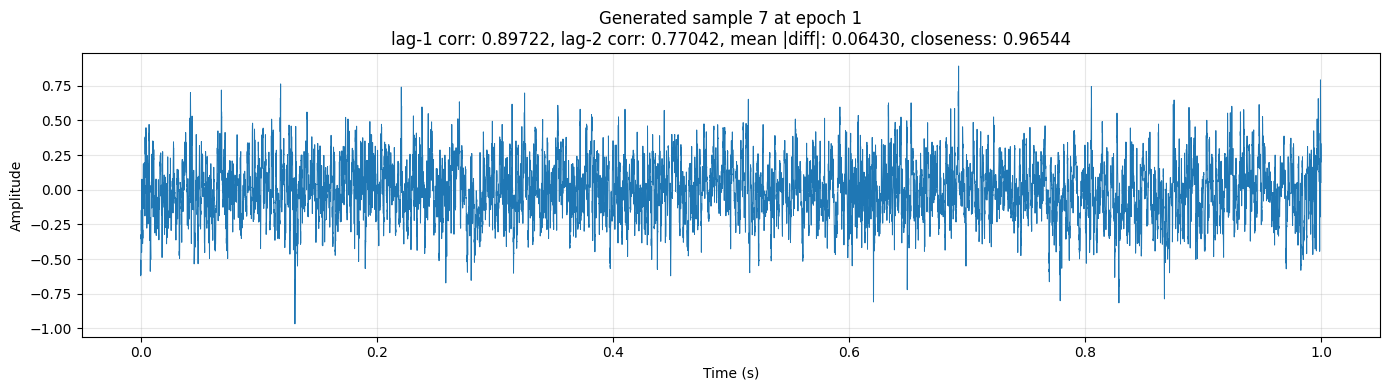

Sample 7


signal shape :  (16000,)


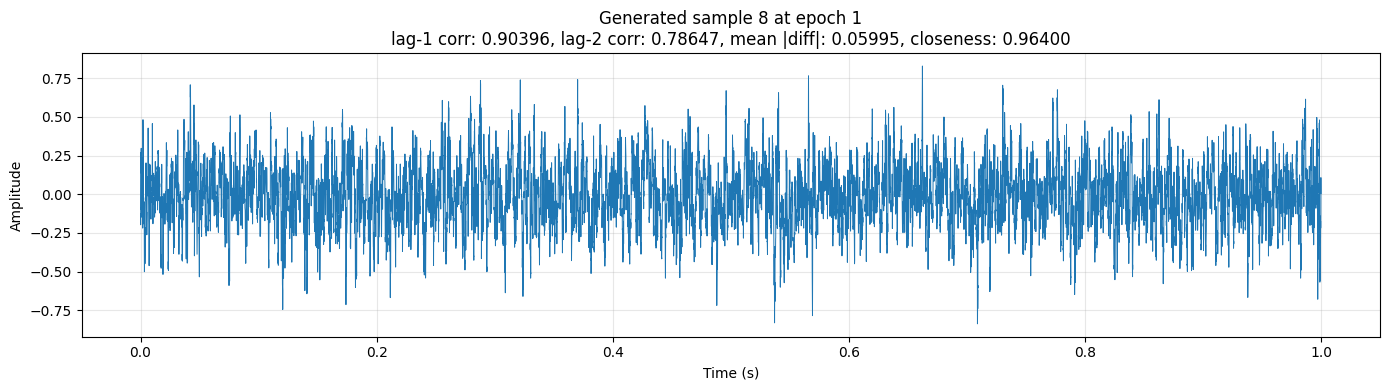

Sample 8


signal shape :  (16000,)


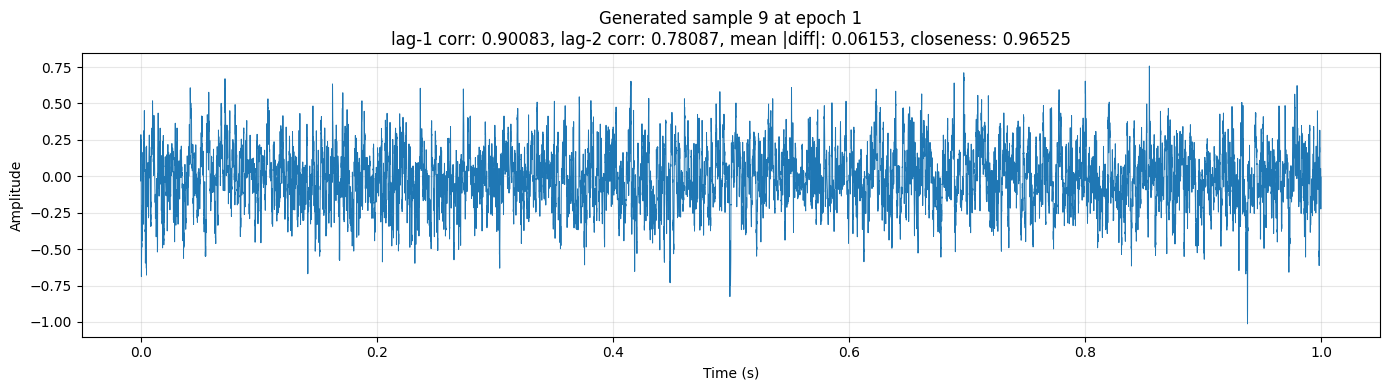

Sample 9


signal shape :  (16000,)


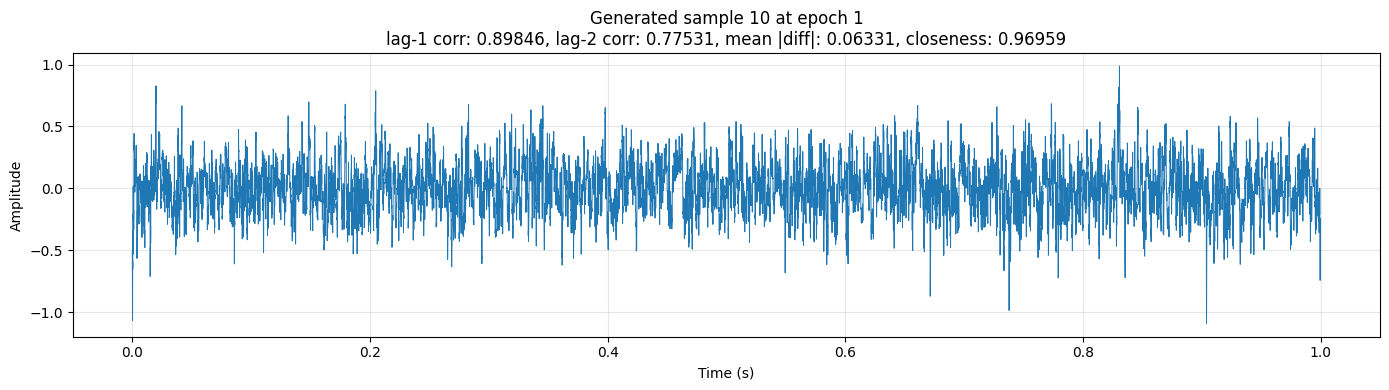

Sample 10


signal shape :  (16000,)


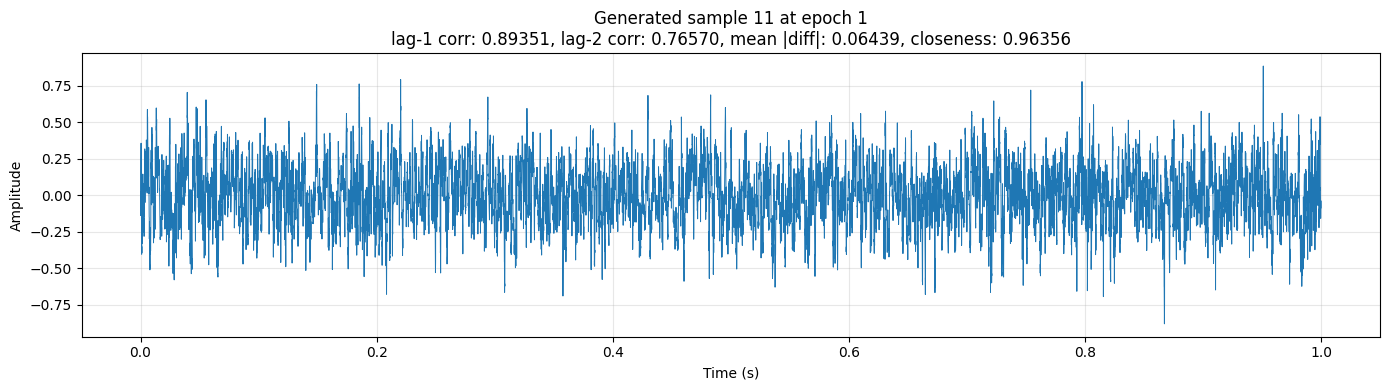

Sample 11


signal shape :  (16000,)


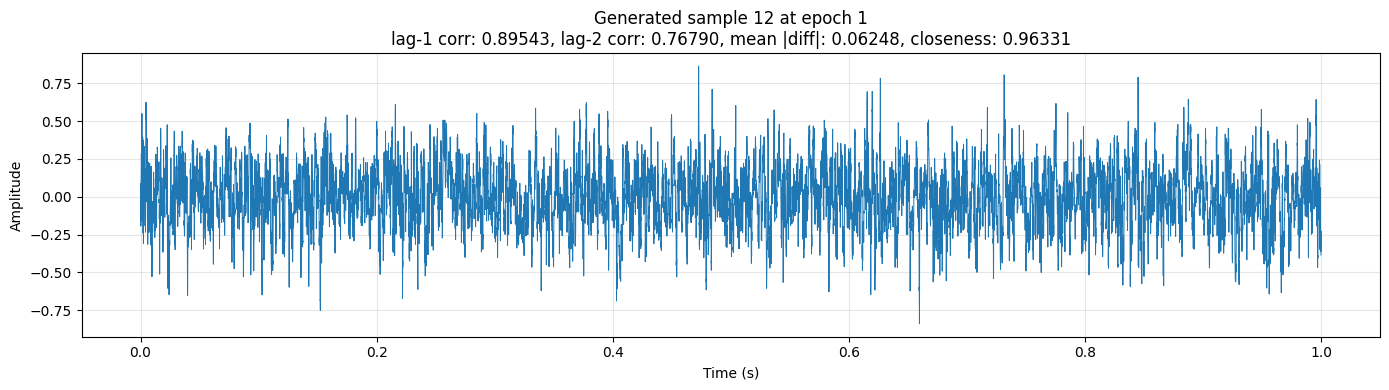

Sample 12


epoch  1


Epoch 2/200:   4%|▍         | 42/999 [01:43<39:08,  2.45s/it, loss=-1.650301, lr=1.00e-04]


KeyboardInterrupt: 

In [36]:


num_epochs = 2 if config.DEBUG else config.EPOCHS

print("creating model ...")
model = Glow1D(
    in_channels=config.IN_CHANNELS,
    seq_len=config.SEQ_LEN,
    hidden_channels=config.HIDDEN_CHANNELS,
).to(device)

print("model created ...")
optimizer = torch.optim.Adamax(
    model.parameters(),
    lr=config.BASE_LR,
    betas=(0.9, 0.999),
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,   # every 20 epochs
    gamma=1/3       # divide by 3
)
print("starting trainign loop...")
for epoch in range(num_epochs):
    epoch_start_time = time.time()
    print("epoch ",epoch)
    if config.DEBUG:
      print()

    model.train()
    total_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for step_in_epoch, x in enumerate(progress_bar):
        if config.DEBUG and step_in_epoch >= 20:
            break

        x = x.to(device, non_blocking=True)

        optimizer.zero_grad()
        loss, _ = model(x,step_in_epoch)
        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        current_lr = optimizer.param_groups[0]['lr']  # real LR

        progress_bar.set_postfix(loss=f"{loss.item():.6f}", lr=f"{current_lr:.2e}")

    scheduler.step()
    print(f"Epoch {epoch+1}: average_loss = {total_loss / len(train_loader):.6f}")

    if  not config.DEBUG and ((epoch + 1) % config.PLOT_EVERY == 0 or epoch == 0):
        generate_and_show_signals(
            model,
            epoch=epoch + 1,
            num_samples=12,
            device=device,
        )

